In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from google.colab import drive
drive.mount("/content/drive")
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from scipy import stats
from matplotlib.cm import get_cmap

Mounted at /content/drive


In [2]:
big5_df = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/STA437/big_five_data/big_five_data.csv")

print(f"Respondents: {len(big5_df)}")
print(f"Items: {big5_df.shape[1]}")

Respondents: 19718
Items: 50


In [3]:
reverse_items = [
    "E2", "E4", "E6", "E8", "E10",
    "N2", "N4",
    "A1", "A3", "A5", "A7",
    "C2", "C4", "C6", "C8",
    "O2", "O4", "O6"
]


big5_df_rc = big5_df.copy()
big5_df_rc[reverse_items] = 6 - big5_df_rc[reverse_items]  # Likert 1–5 => reverse as 6-x

domains = ["E", "N", "A", "C", "O"]
items_by_domain = {d: [f"{d}{i}" for i in range(1, 11)] for d in domains}

data overview

/tmp/ipykernel_205/3331179330.py:4: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = get_cmap("Blues")


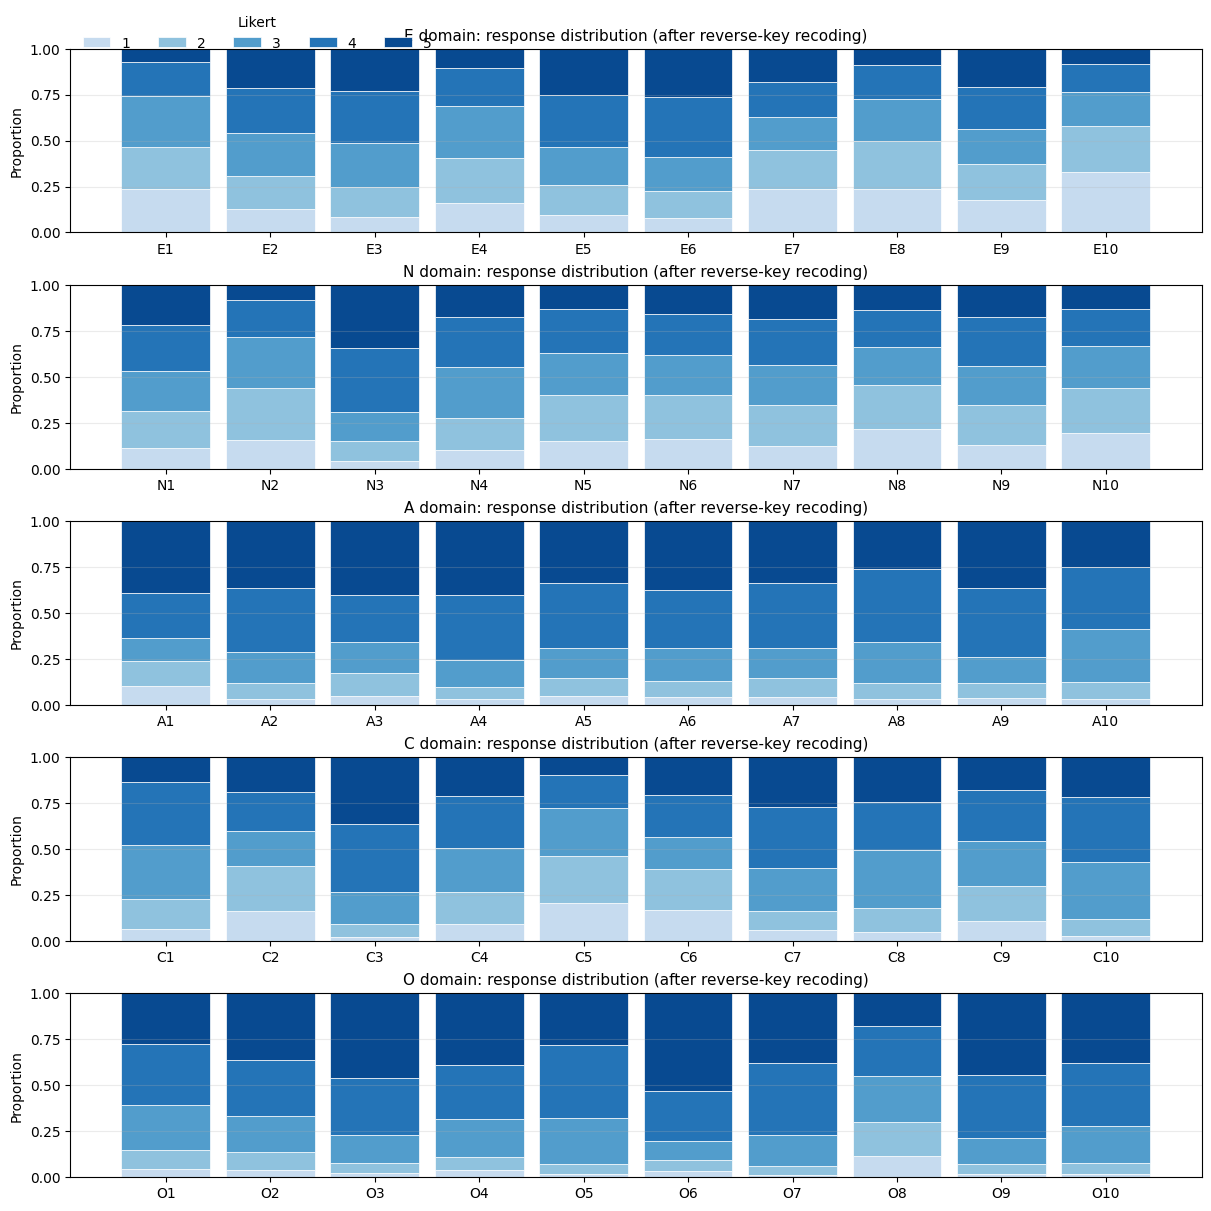

In [4]:
likert_levels = [1, 2, 3, 4, 5]

# Use a sequential colormap for ordered Likert categories
cmap = get_cmap("Blues")
likert_colors = [cmap(x) for x in np.linspace(0.25, 0.90, 5)]

fig, axes = plt.subplots(
    nrows=5, ncols=1, figsize=(12, 12), sharex=False, sharey=True, constrained_layout=True
)

for ax, d in zip(axes, domains):
    items = items_by_domain[d]

    # proportions for each item across Likert levels
    prop = (
        big5_df_rc[items]
        .apply(lambda col: col.value_counts(normalize=True).reindex(likert_levels, fill_value=0.0))
        .T
    )  # shape: (10 items) x (5 levels)

    bottoms = np.zeros(len(items))
    x = np.arange(len(items))

    for j, lvl in enumerate(likert_levels):
        ax.bar(
            x,
            prop[lvl].values,
            bottom=bottoms,
            width=0.85,
            color=likert_colors[j],
            edgecolor="white",
            linewidth=0.5,
            label=str(lvl) if d == "E" else None,  # legend once
        )
        bottoms += prop[lvl].values

    ax.set_title(f"{d} domain: response distribution (after reverse-key recoding)", fontsize=11)
    ax.set_ylim(0, 1)
    ax.set_yticks([0, 0.25, 0.50, 0.75, 1.00])
    ax.set_ylabel("Proportion")
    ax.set_xticks(x)
    ax.set_xticklabels(items, rotation=0)
    ax.grid(axis="y", alpha=0.25)

# Legend outside on the top subplot
axes[0].legend(
    title="Likert",
    ncol=5,
    frameon=False,
    loc="upper left",
    bbox_to_anchor=(0.0, 1.25),
)

plt.show()

In [5]:
item_means = big5_df_rc.mean(axis=0)
item_sds = big5_df_rc.std(axis=0, ddof=1)

summary = pd.DataFrame({"item": item_means.index, "mean": item_means.values, "sd": item_sds.values})
summary["domain"] = summary["item"].str[0]
summary = summary.sort_values("mean", ascending=True).reset_index(drop=True)

domain_colors = {
    "E": "#1f77b4",  # blue
    "N": "#ff7f0e",  # orange
    "A": "#2ca02c",  # green
    "C": "#d62728",  # red
    "O": "#9467bd"   # purple
}

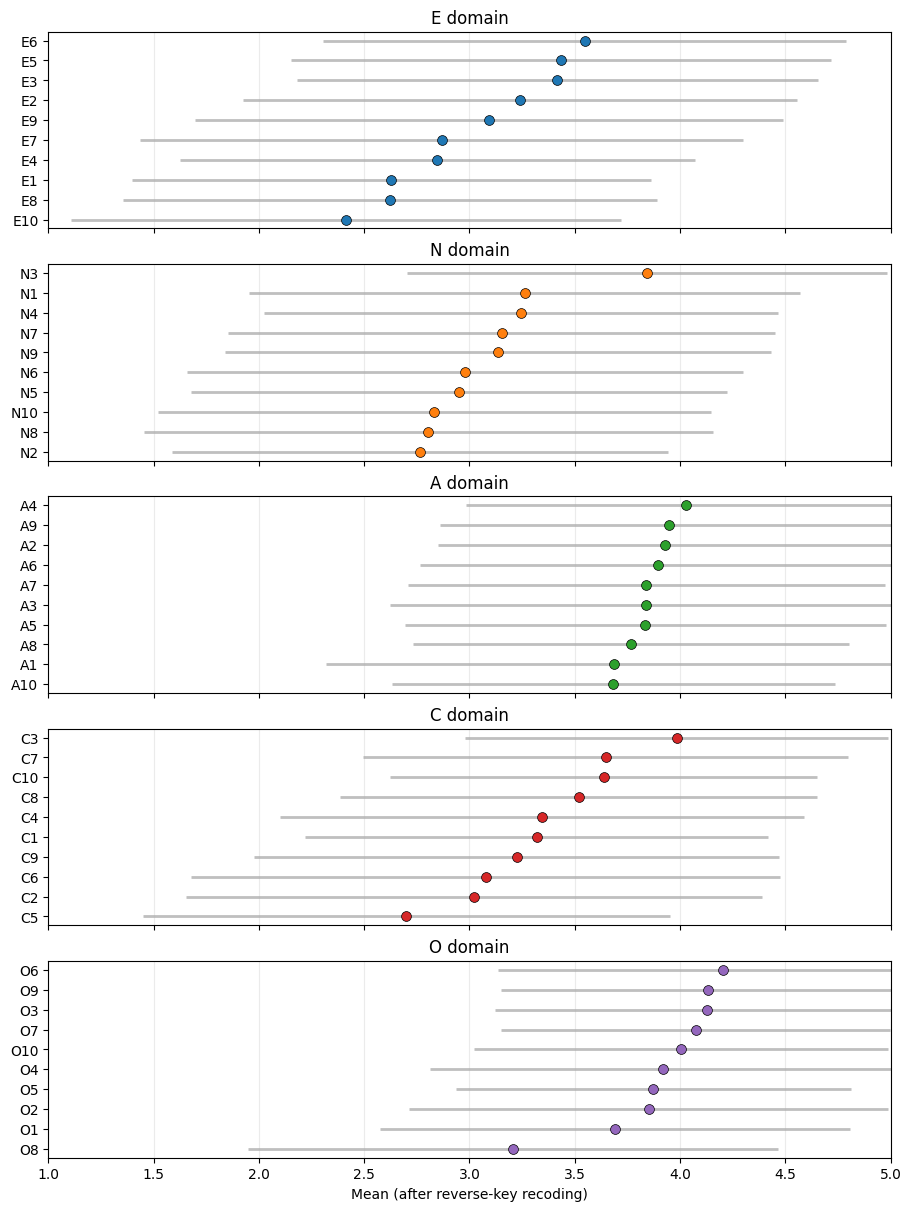

In [6]:
fig, axes = plt.subplots(nrows=5, ncols=1, figsize=(9, 12), sharex=True, constrained_layout=True)

for ax, d in zip(axes, domains):
    sub = summary[summary["domain"] == d].sort_values("mean").reset_index(drop=True)
    yy = np.arange(len(sub))

    ax.hlines(
        y=yy,
        xmin=sub["mean"] - sub["sd"],
        xmax=sub["mean"] + sub["sd"],
        color="0.75",
        linewidth=2,
        zorder=1
    )
    ax.scatter(
        sub["mean"],
        yy,
        s=50,
        color=domain_colors[d],
        edgecolor="black",
        linewidth=0.5,
        zorder=2
    )

    ax.set_yticks(yy)
    ax.set_yticklabels(sub["item"])
    ax.set_title(f"{d} domain")
    ax.grid(axis="x", alpha=0.25)
    ax.set_xlim(1, 5)

axes[-1].set_xlabel("Mean (after reverse-key recoding)")
plt.show()

correlation structure

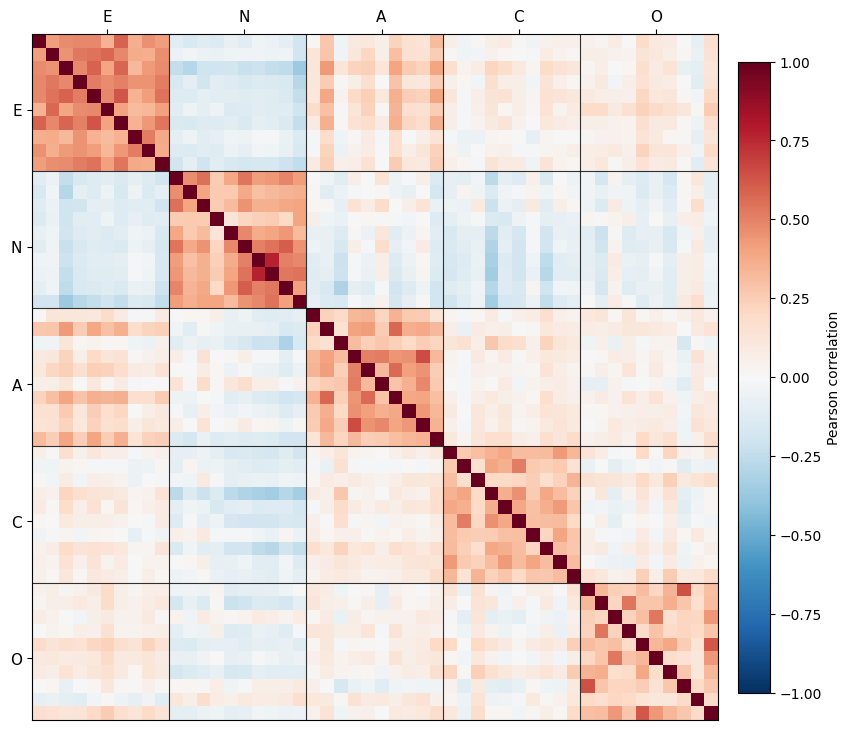

In [8]:
domains = ["E", "N", "A", "C", "O"]
items_by_domain = {d: [f"{d}{i}" for i in range(1, 11)] for d in domains}
ordered_items = sum([items_by_domain[d] for d in domains], [])
# -----------------------------
# 1) Item-level Pearson correlation (50x50)
# -----------------------------
corr_pearson = big5_df_rc[ordered_items].corr(method="pearson")

fig, ax = plt.subplots(figsize=(8.2, 7.2), constrained_layout=True)
im = ax.imshow(corr_pearson.values, vmin=-1, vmax=1, cmap="RdBu_r", interpolation="nearest")

# block dividers
for edge in [10, 20, 30, 40]:
    ax.axhline(edge - 0.5, color="black", linewidth=0.8, alpha=0.8)
    ax.axvline(edge - 0.5, color="black", linewidth=0.8, alpha=0.8)

# only domain labels at block centers (readable)
centers = np.array([5, 15, 25, 35, 45])
ax.set_xticks(centers)
ax.set_yticks(centers)
ax.set_xticklabels(domains, fontsize=11)
ax.set_yticklabels(domains, fontsize=11)
ax.tick_params(top=True, bottom=False, labeltop=True, labelbottom=False)

cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.03)
cbar.set_label("Pearson correlation", rotation=90)

plt.show()

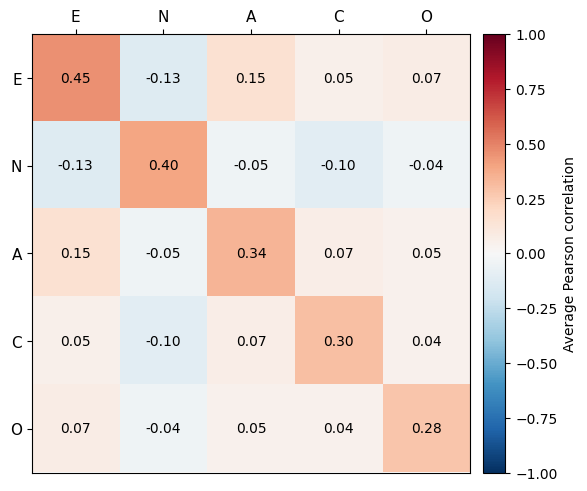

In [9]:
# -----------------------------
# 2) Domain-level average Pearson correlations (5x5)
# -----------------------------
domain_avg = pd.DataFrame(index=domains, columns=domains, dtype=float)

for di in domains:
    for dj in domains:
        block = corr_pearson.loc[items_by_domain[di], items_by_domain[dj]].values
        if di == dj:
            block = block[~np.eye(block.shape[0], dtype=bool)]  # exclude diagonal
        domain_avg.loc[di, dj] = block.mean()

fig, ax = plt.subplots(figsize=(5.6, 4.8), constrained_layout=True)
im = ax.imshow(domain_avg.values, vmin=-1, vmax=1, cmap="RdBu_r", interpolation="nearest")

ax.set_xticks(range(len(domains)))
ax.set_yticks(range(len(domains)))
ax.set_xticklabels(domains, fontsize=11)
ax.set_yticklabels(domains, fontsize=11)
ax.tick_params(top=True, bottom=False, labeltop=True, labelbottom=False)

# annotate values (2 decimals)
for i in range(len(domains)):
    for j in range(len(domains)):
        ax.text(j, i, f"{domain_avg.values[i, j]:.2f}", ha="center", va="center", fontsize=10)
cbar = fig.colorbar(im, ax=ax, fraction=0.05, pad=0.03)
cbar.set_label("Average Pearson correlation", rotation=90)

plt.show()

In [10]:
from scipy.stats import norm, multivariate_normal
from scipy.optimize import minimize_scalar

# ----------------------------
# Polychoric correlation helpers
# ----------------------------
def _thresholds_from_marginal(x, n_cats=5):
    """
    Estimate thresholds tau_1..tau_{K-1} from marginal proportions.
    For K=5, returns 4 thresholds.
    """
    x = np.asarray(x).astype(int)
    counts = np.bincount(x, minlength=n_cats + 1)[1:]  # categories 1..K
    probs = counts / counts.sum()
    cdf = np.cumsum(probs)[:-1]  # up to K-1
    # guard against 0 or 1
    cdf = np.clip(cdf, 1e-6, 1 - 1e-6)
    return norm.ppf(cdf)

def _rect_prob(rho, ax0, ax1, by0, by1):
    """
    P(ax0 < X <= ax1, by0 < Y <= by1) for bivariate normal with corr=rho.
    Uses inclusion-exclusion on CDF corners.
    """
    mean = np.array([0.0, 0.0])
    cov = np.array([[1.0, rho], [rho, 1.0]])

    def cdf(u, v):
        if np.isneginf(u) or np.isneginf(v):
            return 0.0
        if np.isposinf(u) and np.isposinf(v):
            return 1.0
        if np.isposinf(u):
            return norm.cdf(v)  # X is +inf, reduces to marginal of Y
        if np.isposinf(v):
            return norm.cdf(u)  # Y is +inf, reduces to marginal of X
        return multivariate_normal.cdf([u, v], mean=mean, cov=cov)

    return max(
        0.0,
        cdf(ax1, by1) - cdf(ax0, by1) - cdf(ax1, by0) + cdf(ax0, by0)
    )

def polychoric_corr_pair(x, y, n_cats=5):
    """
    Estimate polychoric correlation for two ordinal variables in {1..K}.
    Thresholds are fixed from marginals; rho is ML-estimated.
    """
    x = np.asarray(x).astype(int)
    y = np.asarray(y).astype(int)

    # contingency table counts (KxK)
    tab = pd.crosstab(x, y).reindex(
        index=range(1, n_cats + 1), columns=range(1, n_cats + 1), fill_value=0
    ).values

    tx = _thresholds_from_marginal(x, n_cats=n_cats)
    ty = _thresholds_from_marginal(y, n_cats=n_cats)

    # bounds arrays with -inf/+inf
    bx = np.concatenate(([-np.inf], tx, [np.inf]))
    by = np.concatenate(([-np.inf], ty, [np.inf]))

    eps = 1e-12

    def neg_loglik(rho):
        ll = 0.0
        for i in range(n_cats):
            for j in range(n_cats):
                n_ij = tab[i, j]
                if n_ij == 0:
                    continue
                p_ij = _rect_prob(rho, bx[i], bx[i + 1], by[j], by[j + 1])
                ll += n_ij * np.log(max(p_ij, eps))
        return -ll

    res = minimize_scalar(neg_loglik, bounds=(-0.999, 0.999), method="bounded")
    return float(res.x)

def polychoric_corr_matrix(df_ord, cols, n_cats=5):
    """
    Compute a polychoric correlation matrix for given columns.
    df_ord must contain integer codes 1..K.
    """
    X = df_ord[cols].to_numpy()
    p = len(cols)
    R = np.eye(p)

    # precompute marginals thresholds once (optional), but pairwise ML dominates time anyway
    for i in range(p):
        for j in range(i + 1, p):
            rho = polychoric_corr_pair(X[:, i], X[:, j], n_cats=n_cats)
            R[i, j] = rho
            R[j, i] = rho
    return pd.DataFrame(R, index=cols, columns=cols)

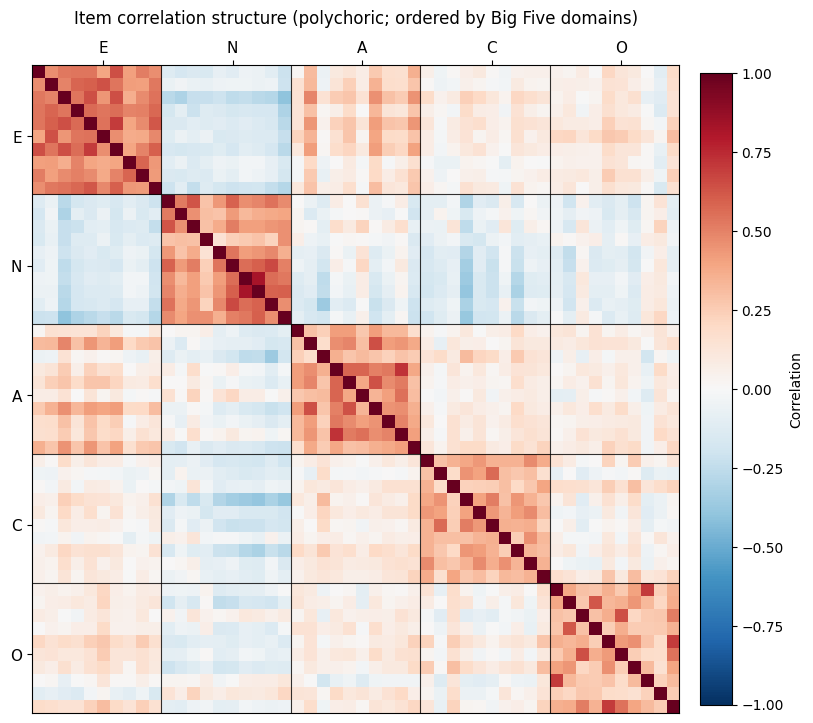

In [11]:
# ----------------------------
# Build correlation matrices
# ----------------------------
domains = ["E", "N", "A", "C", "O"]
items_by_domain = {d: [f"{d}{i}" for i in range(1, 11)] for d in domains}
ordered_items = sum([items_by_domain[d] for d in domains], [])

# big5_df_rc should already be reverse-key recoded and still in 1..5 integers
# Ensure integer type for polychoric
big5_ord = big5_df_rc[ordered_items].round().astype(int)

# Polychoric (main)
corr_poly = polychoric_corr_matrix(big5_ord, ordered_items, n_cats=5)

# Pearson (optional baseline)
corr_pearson = big5_ord.corr(method="pearson")

# ----------------------------
# Plot: block-structured heatmap (readable)
# ----------------------------
def plot_block_heatmap(corr_df, title):
    fig, ax = plt.subplots(figsize=(8.2, 7.2), constrained_layout=True)
    im = ax.imshow(corr_df.values, vmin=-1, vmax=1, cmap="RdBu_r", interpolation="nearest")

    # block dividers
    for edge in [10, 20, 30, 40]:
        ax.axhline(edge - 0.5, color="black", linewidth=0.8, alpha=0.8)
        ax.axvline(edge - 0.5, color="black", linewidth=0.8, alpha=0.8)

    centers = np.array([5, 15, 25, 35, 45])
    ax.set_xticks(centers)
    ax.set_yticks(centers)
    ax.set_xticklabels(domains, fontsize=11)
    ax.set_yticklabels(domains, fontsize=11)
    ax.tick_params(top=True, bottom=False, labeltop=True, labelbottom=False)

    ax.set_title(title, fontsize=12, pad=12)

    cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.03)
    cbar.set_label("Correlation", rotation=90)
    plt.show()

plot_block_heatmap(corr_poly, "Item correlation structure (polychoric; ordered by Big Five domains)")

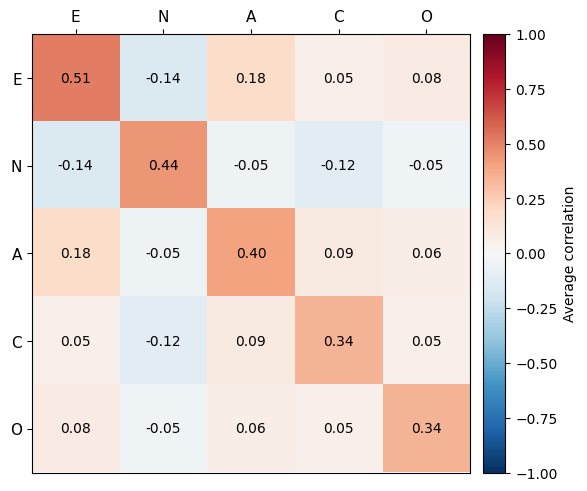

In [12]:
corr = corr_poly

domain_avg = pd.DataFrame(index=domains, columns=domains, dtype=float)

for di in domains:
    for dj in domains:
        block = corr.loc[items_by_domain[di], items_by_domain[dj]].values
        if di == dj:
            # exclude diagonal (self correlations)
            block = block[~np.eye(block.shape[0], dtype=bool)]
        domain_avg.loc[di, dj] = block.mean()

fig, ax = plt.subplots(figsize=(5.6, 4.8), constrained_layout=True)
im = ax.imshow(domain_avg.values, vmin=-1, vmax=1, cmap="RdBu_r", interpolation="nearest")

ax.set_xticks(range(len(domains)))
ax.set_yticks(range(len(domains)))
ax.set_xticklabels(domains, fontsize=11)
ax.set_yticklabels(domains, fontsize=11)
ax.tick_params(top=True, bottom=False, labeltop=True, labelbottom=False)

# annotate cells (readable, 2 decimals)
for i in range(len(domains)):
    for j in range(len(domains)):
        ax.text(j, i, f"{domain_avg.values[i, j]:.2f}", ha="center", va="center", fontsize=10)

cbar = fig.colorbar(im, ax=ax, fraction=0.05, pad=0.03)
cbar.set_label("Average correlation", rotation=90)

plt.show()

/tmp/ipykernel_205/2029368630.py:21: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(


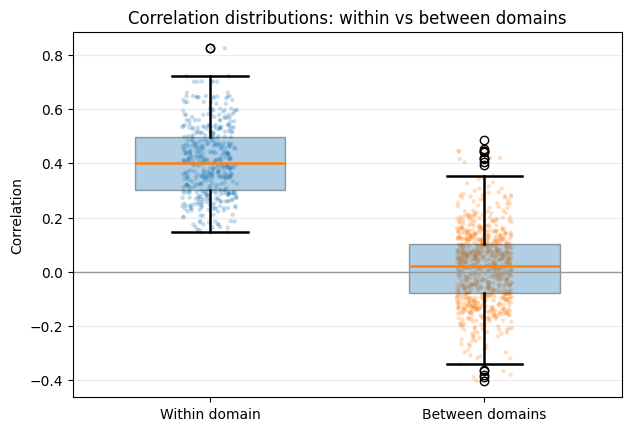

In [13]:
within_vals = []
between_vals = []

for i, di in enumerate(domains):
    for j, dj in enumerate(domains):
        block = corr.loc[items_by_domain[di], items_by_domain[dj]].values

        if di == dj:
            # exclude diagonal
            mask = ~np.eye(block.shape[0], dtype=bool)
            within_vals.extend(block[mask].ravel().tolist())
        elif j > i:
            # only take upper triangle blocks once (avoid double counting)
            between_vals.extend(block.ravel().tolist())

data = [within_vals, between_vals]
labels = ["Within domain", "Between domains"]

fig, ax = plt.subplots(figsize=(6.2, 4.2), constrained_layout=True)

bp = ax.boxplot(
    data,
    labels=labels,
    patch_artist=True,
    showfliers=True,
    widths=0.55
)

# Keep styling simple + readable
for patch in bp["boxes"]:
    patch.set_alpha(0.35)
for k in ["whiskers", "caps", "medians"]:
    for line in bp[k]:
        line.set_linewidth(1.8)

# jittered points (subsample for readability)
rng = np.random.default_rng(0)
def jitter(x0, n, width=0.10):
    return x0 + rng.uniform(-width, width, size=n)

sample_n = 800
w = np.array(within_vals)
b = np.array(between_vals)
if len(w) > sample_n: w = rng.choice(w, size=sample_n, replace=False)
if len(b) > sample_n: b = rng.choice(b, size=sample_n, replace=False)

ax.scatter(jitter(1, len(w)), w, s=10, alpha=0.25, edgecolors="none")
ax.scatter(jitter(2, len(b)), b, s=10, alpha=0.25, edgecolors="none")

ax.axhline(0, color="0.6", linewidth=1)
ax.set_ylabel("Correlation")
ax.set_title("Correlation distributions: within vs between domains")
ax.grid(axis="y", alpha=0.25)


MVN assumption check

Mardia MVN tests (on a random subsample)
n = 3000, p = 50
Skewness: b1p = 104.6652, chi2 = 52332.58, df = 22100, p = 0
Kurtosis: b2p = 3080.08, z = 182.32, p = 0


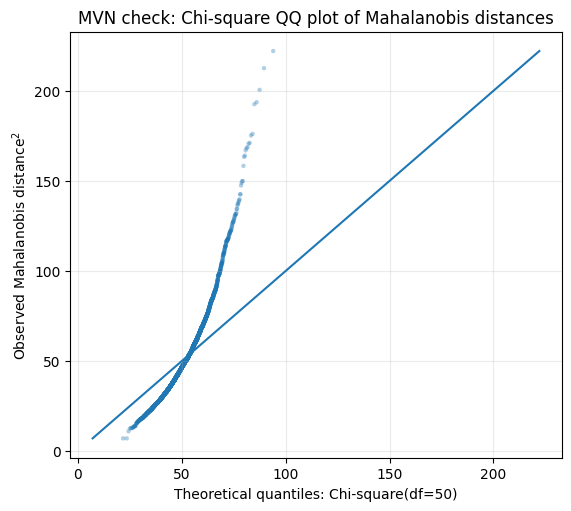

In [14]:
from scipy.stats import chi2, norm
def mardia_mvn_test(X: np.ndarray):
    """
    Mardia's multivariate skewness and kurtosis tests for MVN.
    Returns a dict with statistics and p-values.
    """
    X = np.asarray(X, dtype=float)
    n, p = X.shape

    mu = X.mean(axis=0, keepdims=True)
    Xc = X - mu

    S = np.cov(Xc, rowvar=False, bias=False)
    invS = np.linalg.pinv(S)  # pinv is safer than inv

    # Mahalanobis distances squared: d_i = (x_i-mu)' invS (x_i-mu)
    d = np.einsum("ij,jk,ik->i", Xc, invS, Xc)

    # Pairwise quadratic forms: a_ij = (x_i-mu)' invS (x_j-mu)
    A = Xc @ invS @ Xc.T

    # Mardia skewness b1p
    b1p = np.mean(A**3)

    # Mardia kurtosis b2p
    b2p = np.mean(d**2)

    # Skewness test
    df_skew = p * (p + 1) * (p + 2) / 6
    chi_skew = n * b1p / 6
    p_skew = 1 - chi2.cdf(chi_skew, df=df_skew)

    # Kurtosis test (normal approx)
    expected_b2p = p * (p + 2)
    var_b2p = (8 * p * (p + 2)) / n
    z_kurt = (b2p - expected_b2p) / np.sqrt(var_b2p)
    p_kurt = 2 * (1 - norm.cdf(abs(z_kurt)))

    return {
        "n": n, "p": p,
        "b1p_skewness": b1p,
        "chi2_stat_skewness": chi_skew,
        "df_skewness": df_skew,
        "p_value_skewness": p_skew,
        "b2p_kurtosis": b2p,
        "z_stat_kurtosis": z_kurt,
        "p_value_kurtosis": p_kurt,
        "mahalanobis_d2": d,
    }

def mvn_qq_plot(mahal_d2, p, title="MVN check: Chi-square QQ plot of Mahalanobis distances"):
    """
    QQ plot of Mahalanobis distance^2 against Chi-square(p).
    """
    d_sorted = np.sort(mahal_d2)
    n = len(d_sorted)
    probs = (np.arange(1, n + 1) - 0.5) / n
    q = chi2.ppf(probs, df=p)

    fig, ax = plt.subplots(figsize=(5.6, 5.0), constrained_layout=True)
    ax.scatter(q, d_sorted, s=10, alpha=0.35, edgecolors="none")
    lo = min(q.min(), d_sorted.min())
    hi = max(q.max(), d_sorted.max())
    ax.plot([lo, hi], [lo, hi], linewidth=1.5)
    ax.set_xlabel(f"Theoretical quantiles: Chi-square(df={p})")
    ax.set_ylabel("Observed Mahalanobis distance$^2$")
    ax.set_title(title)
    ax.grid(alpha=0.25)
    plt.show()

# -------------------------
# Practical usage
# -------------------------
# MVN tests can be heavy for n=19718, p=50 because they involve a 19718x19718 matrix if run on all rows.
# Use a random subsample for the test and QQ plot.
rng = np.random.default_rng(0)
n_sub = 3000
idx = rng.choice(big5_df_rc.shape[0], size=min(n_sub, big5_df_rc.shape[0]), replace=False)

X = big5_df_rc.loc[idx, ordered_items].astype(float).to_numpy()

# Standardize before MVN diagnostics (center and scale)
X = (X - X.mean(axis=0)) / X.std(axis=0, ddof=1)

res = mardia_mvn_test(X)

print("Mardia MVN tests (on a random subsample)")
print(f"n = {res['n']}, p = {res['p']}")
print(f"Skewness: b1p = {res['b1p_skewness']:.4f}, chi2 = {res['chi2_stat_skewness']:.2f}, "
      f"df = {res['df_skewness']:.0f}, p = {res['p_value_skewness']:.3g}")
print(f"Kurtosis: b2p = {res['b2p_kurtosis']:.2f}, z = {res['z_stat_kurtosis']:.2f}, "
      f"p = {res['p_value_kurtosis']:.3g}")

mvn_qq_plot(res["mahalanobis_d2"], p=res["p"])

KMO analysis

In [15]:
def kmo_from_corr(R: np.ndarray):
    """
    Compute KMO overall and per-variable KMO from a correlation matrix.
    Returns: (kmo_overall, kmo_per_item)
    """
    R = np.asarray(R, dtype=float)
    p = R.shape[0]
    if R.shape[0] != R.shape[1]:
        raise ValueError("R must be a square correlation matrix.")

    # Invert correlation matrix to get partial correlations
    invR = np.linalg.inv(R)

    # Partial correlation matrix
    P = np.zeros_like(R)
    for i in range(p):
        for j in range(p):
            if i == j:
                P[i, j] = 0.0
            else:
                P[i, j] = -invR[i, j] / np.sqrt(invR[i, i] * invR[j, j])

    # Use squared correlations / partial correlations (excluding diagonal)
    R2 = R**2
    P2 = P**2
    np.fill_diagonal(R2, 0.0)
    np.fill_diagonal(P2, 0.0)

    # Per-variable KMO
    num_i = R2.sum(axis=0)
    den_i = num_i + P2.sum(axis=0)
    kmo_i = num_i / den_i

    # Overall KMO
    num = R2.sum()
    den = num + P2.sum()
    kmo_overall = num / den

    return float(kmo_overall), kmo_i

R = corr_poly.loc[ordered_items, ordered_items].values


kmo_overall, kmo_item = kmo_from_corr(R)

kmo_table = pd.DataFrame({"item": ordered_items, "KMO": kmo_item})
kmo_table["domain"] = kmo_table["item"].str[0]

print(f"Overall KMO: {kmo_overall:.3f}")
display(kmo_table.sort_values("KMO"))

Overall KMO: 0.913


,item,KMO,domain
47,O8,0.756828,O
40,O1,0.782330,O
42,O3,0.807893,O
43,O4,0.823440,O
45,O6,0.833447,O
41,O2,0.844588,O
31,C2,0.863371,C
17,N8,0.866625,N
49,O10,0.867722,O
16,N7,0.871479,N


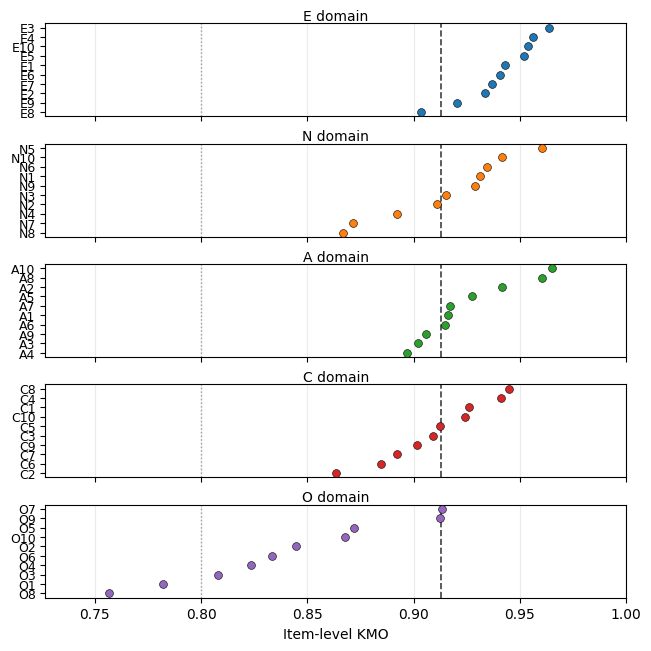

In [16]:
domain_colors = {"E":"#1f77b4","N":"#ff7f0e","A":"#2ca02c","C":"#d62728","O":"#9467bd"}

fig, axes = plt.subplots(
    nrows=5, ncols=1,
    figsize=(6.4, 6.4),
    sharex=True,
    constrained_layout=True
)

xmin = max(0.6, float(kmo_table["KMO"].min()) - 0.03)

for ax, d in zip(axes, domains):
    sub = kmo_table[kmo_table["domain"] == d].sort_values("KMO").reset_index(drop=True)
    y = np.arange(len(sub))

    ax.scatter(
        sub["KMO"], y,
        s=32,
        color=domain_colors[d],
        edgecolor="black",
        linewidth=0.4,
        zorder=3
    )

    ax.set_yticks(y)
    ax.set_yticklabels(sub["item"], fontsize=9)
    ax.set_title(f"{d} domain", fontsize=10, pad=2)

    ax.grid(axis="x", alpha=0.25)
    ax.set_xlim(xmin, 1.0)

    # overall KMO reference line
    ax.axvline(kmo_overall, color="0.25", linewidth=1.2, linestyle="--", zorder=2)

    ax.axvline(0.80, color="0.6", linewidth=1.0, linestyle=":", zorder=1)

# labels + compact title
axes[-1].set_xlabel("Item-level KMO", fontsize=10)

plt.show()

PCA baseline

In [17]:
X = big5_df_rc[ordered_items].astype(float).to_numpy()

# standardize -> correlation PCA
X = (X - X.mean(axis=0)) / X.std(axis=0, ddof=1)

R = np.corrcoef(X, rowvar=False)  # correlation matrix (p x p)

eigvals, eigvecs = np.linalg.eigh(R)              # eigh since R is symmetric
eigvals = eigvals[::-1]                           # descending
eigvecs = eigvecs[:, ::-1]

explained_ratio = eigvals / eigvals.sum()
cum_explained = np.cumsum(explained_ratio)

scores = X @ eigvecs                              # PCA scores (n x p) for correlation PCA
loadings = eigvecs * np.sqrt(eigvals)             # correlation loadings (p x p)

# quick table (optional)
pca_summary = pd.DataFrame({
    "PC": np.arange(1, len(eigvals) + 1),
    "eigenvalue": eigvals,
    "prop_var": explained_ratio,
    "cum_var": cum_explained
})
display(pca_summary.head(12))

,PC,eigenvalue,prop_var,cum_var
0,1,8.050137,0.161003,0.161003
1,2,4.615016,0.092300,0.253303
2,3,3.747976,0.074960,0.328263
3,4,3.552579,0.071052,0.399314
4,5,2.763873,0.055277,0.454592
5,6,1.573764,0.031475,0.486067
6,7,1.328872,0.026577,0.512644
7,8,1.054032,0.021081,0.533725
8,9,0.966648,0.019333,0.553058
9,10,0.926480,0.018530,0.571588


Parallel analysis

In [18]:
def parallel_analysis_perm(Xz, B=200, q=0.95, random_state=0):
    """
    Permutation parallel analysis for correlation PCA.
    Xz: standardized data (n x p)
    B: number of permutations
    q: quantile for threshold (e.g., 0.95)
    Returns: mean_eigs, q_eigs
    """
    rng = np.random.default_rng(random_state)
    n, p = Xz.shape
    rand_eigs = np.empty((B, p), dtype=float)

    for b in range(B):
        Xp = Xz.copy()
        # permute each column independently
        for j in range(p):
            rng.shuffle(Xp[:, j])
        Rp = np.corrcoef(Xp, rowvar=False)
        ev = np.linalg.eigvalsh(Rp)[::-1]  # descending
        rand_eigs[b, :] = ev

    mean_eigs = rand_eigs.mean(axis=0)
    q_eigs = np.quantile(rand_eigs, q=q, axis=0)
    return mean_eigs, q_eigs

B = 500
q = 0.95         # common choice is 0.95
mean_eigs, q_eigs = parallel_analysis_perm(X, B=B, q=q, random_state=0)

# suggested number of components: observed eigenvalues > q-quantile random eigenvalues
k_pa = int(np.sum(eigvals > q_eigs))
print(f"Parallel analysis suggestion (q={q}, B={B}): retain k = {k_pa} components")

Parallel analysis suggestion (q=0.95, B=500): retain k = 7 components


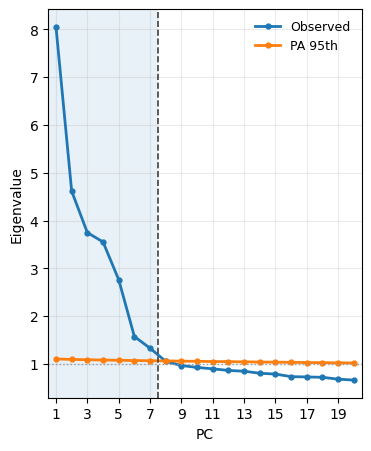

In [19]:
p = len(eigvals)
pcs = np.arange(1, p + 1)

max_pc = min(20, p)
pcs_s = pcs[:max_pc]
obs_s = eigvals[:max_pc]
pa_s  = q_eigs[:max_pc]

# narrower and taller (good for subfigure right column)
fig, ax = plt.subplots(figsize=(3.6, 4.4), constrained_layout=True)

ax.plot(pcs_s, obs_s, marker="o", linewidth=2.0, markersize=3.5, label="Observed")
ax.plot(pcs_s, pa_s,  marker="o", linewidth=2.0, markersize=3.5, label="PA 95th")

k_show = min(k_pa, max_pc)
if k_show >= 1:
    ax.axvspan(0.5, k_show + 0.5, alpha=0.10)

ax.axhline(1.0, color="0.6", linewidth=1.0, linestyle=":")
ax.axvline(k_show + 0.5, color="0.25", linewidth=1.2, linestyle="--")

ax.set_xlim(0.5, max_pc + 0.5)
ax.set_xticks(np.arange(1, max_pc + 1, 2))
ax.set_ylabel("Eigenvalue")
ax.set_xlabel("PC")
ax.grid(alpha=0.25)

# compact legend so it doesn't eat space
ax.legend(frameon=False, loc="upper right", fontsize=9)

plt.show()

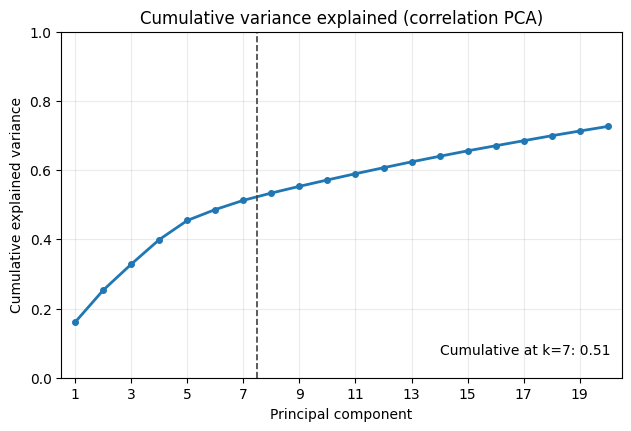

In [20]:
cum = np.cumsum(explained_ratio)
p = len(cum)
pcs = np.arange(1, p + 1)

max_pc = min(20, p)

fig, ax = plt.subplots(figsize=(6.2, 4.2), constrained_layout=True)
ax.plot(pcs[:max_pc], cum[:max_pc], marker="o", linewidth=2.0, markersize=4)

k_show = min(k_pa, max_pc)
ax.axvline(k_show + 0.5, color="0.25", linewidth=1.2, linestyle="--")

ax.set_xlim(0.5, max_pc + 0.5)
ax.set_ylim(0, 1.0)
ax.set_xticks(np.arange(1, max_pc + 1, 2))
ax.set_xlabel("Principal component")
ax.set_ylabel("Cumulative explained variance")
ax.set_title("Cumulative variance explained (correlation PCA)")
ax.grid(alpha=0.25)

ax.text(
    0.98, 0.06,
    f"Cumulative at k={k_pa}: {cum[k_pa-1]:.2f}",
    transform=ax.transAxes,
    ha="right", va="bottom",
    fontsize=10
)

plt.show()

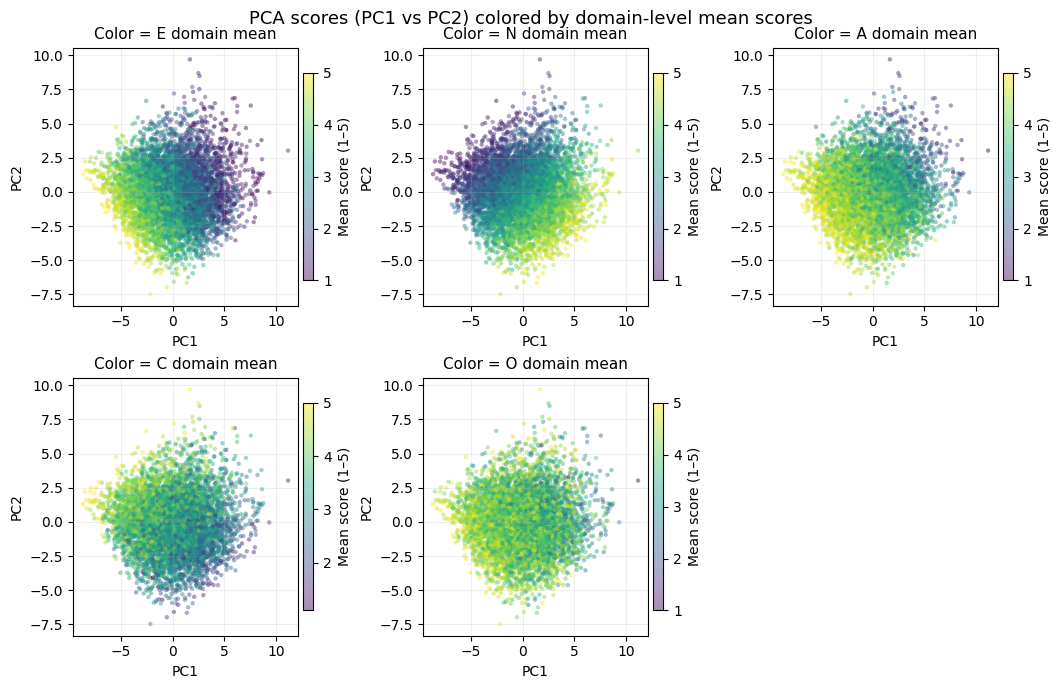

In [21]:
# -----------------------------
# 1) PCA scores for PC1, PC2 (correlation PCA)
# -----------------------------
X = big5_df_rc[ordered_items].astype(float).to_numpy()
Xz = (X - X.mean(axis=0)) / X.std(axis=0, ddof=1)   # standardize
scores = Xz @ eigvecs                               # (n x p)

pc1 = scores[:, 0]
pc2 = scores[:, 1]

# -----------------------------
# 2) Domain-level mean scores (on reverse-key recoded data)
# -----------------------------
domain_means = pd.DataFrame({
    d: big5_df_rc[items_by_domain[d]].mean(axis=1).values
    for d in domains
})

# -----------------------------
# 3) PC1–PC2 scatter, colored by each domain score (facets)
#    - subsample for readability (n is large)
# -----------------------------
rng = np.random.default_rng(0)
n = len(big5_df_rc)
n_plot = min(6000, n)  # increase/decrease for density
idx = rng.choice(n, size=n_plot, replace=False)

fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(10.5, 6.6), constrained_layout=True)
axes = axes.ravel()

# 5 panels only; leave the 6th blank
for k, d in enumerate(domains):
    ax = axes[k]
    c = domain_means.loc[idx, d].values

    sc = ax.scatter(
        pc1[idx], pc2[idx],
        c=c,
        s=10,
        alpha=0.45,
        edgecolors="none"
    )

    ax.set_title(f"Color = {d} domain mean", fontsize=11)
    ax.set_xlabel("PC1")
    ax.set_ylabel("PC2")
    ax.grid(alpha=0.2)

    cbar = fig.colorbar(sc, ax=ax, fraction=0.046, pad=0.02)
    cbar.set_label("Mean score (1–5)", rotation=90)

# hide last axis
axes[-1].axis("off")

fig.suptitle("PCA scores (PC1 vs PC2) colored by domain-level mean scores", fontsize=13, y=1.02)
plt.show()

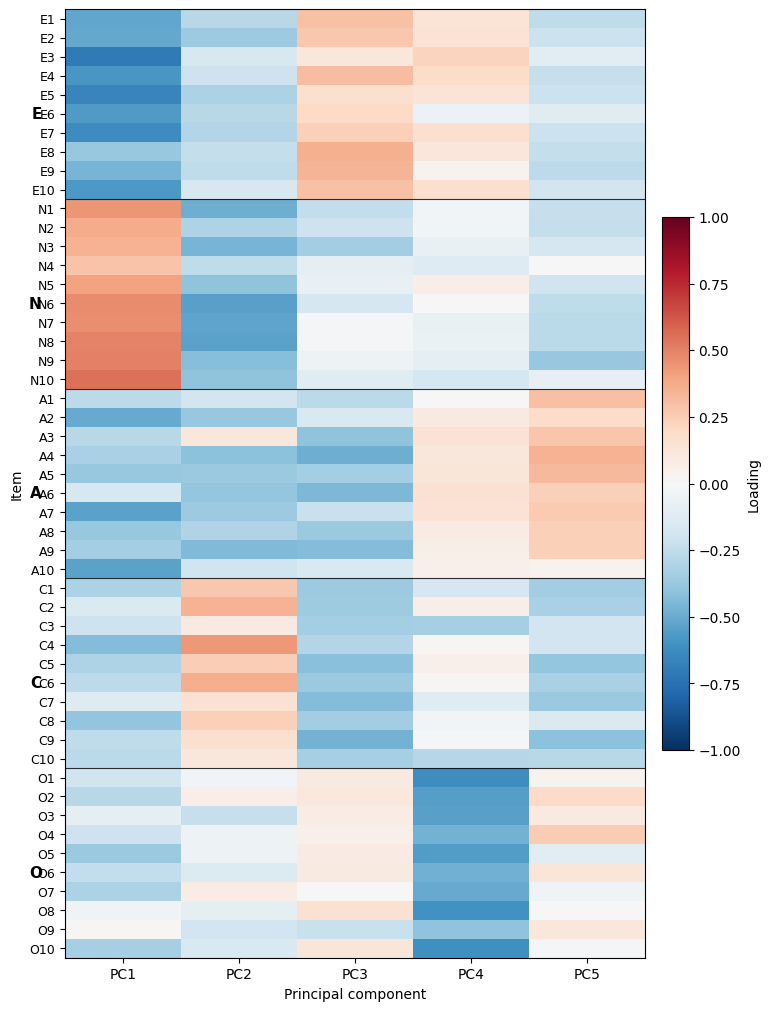

In [22]:
k = 5
loadings = eigvecs[:, :k] * np.sqrt(eigvals[:k])  # shape: (50, k)

load_df = pd.DataFrame(loadings, index=ordered_items, columns=[f"PC{i}" for i in range(1, k + 1)])
load_df["domain"] = load_df.index.str[0]

# -----------------------------
# Heatmap of loadings (items ordered by domain)
# -----------------------------
M = load_df.drop(columns=["domain"]).values

fig, ax = plt.subplots(figsize=(7.6, 10.0), constrained_layout=True)
im = ax.imshow(M, aspect="auto", cmap="RdBu_r", vmin=-1, vmax=1)

# y labels: items
ax.set_yticks(np.arange(len(ordered_items)))
ax.set_yticklabels(ordered_items, fontsize=9)

# x labels: PCs
ax.set_xticks(np.arange(k))
ax.set_xticklabels([f"PC{i}" for i in range(1, k + 1)], fontsize=10)

ax.set_xlabel("Principal component")
ax.set_ylabel("Item")
ax.grid(False)

# domain block dividers (every 10 items)
for edge in [10, 20, 30, 40]:
    ax.axhline(edge - 0.5, color="black", linewidth=0.8, alpha=0.8)

# annotate domain labels on the left margin (optional but helps readability)
centers = [5, 15, 25, 35, 45]
domains = ["E", "N", "A", "C", "O"]
for c, d in zip(centers, domains):
    ax.text(-0.7, c, d, va="center", ha="right", fontsize=11, fontweight="bold")

cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.03)
cbar.set_label("Loading", rotation=90)

plt.show()

factor analysis

In [23]:
R = corr_poly.loc[ordered_items, ordered_items].values
eigvals = np.linalg.eigvalsh(R)[::-1]

# permutation PA on ordinal data (permute columns, then compute polychoric is too slow),
# so for FA we typically use PA baseline on Pearson from permuted data as a conservative screen,
# and then confirm interpretability with FA on polychoric. This is a common practical compromise.
X = big5_df_rc[ordered_items].astype(float).to_numpy()
rng = np.random.default_rng(0)
Xz = (X - X.mean(axis=0)) / X.std(axis=0, ddof=1)

def pa_perm_pearson(Xz, B=500, q=0.95, random_state=0):
    rng = np.random.default_rng(random_state)
    n, p = Xz.shape
    rand_eigs = np.empty((B, p))
    for b in range(B):
        Xp = Xz.copy()
        for j in range(p):
            rng.shuffle(Xp[:, j])
        Rp = np.corrcoef(Xp, rowvar=False)
        rand_eigs[b, :] = np.linalg.eigvalsh(Rp)[::-1]
    return rand_eigs.mean(axis=0), np.quantile(rand_eigs, q=q, axis=0)

B = 500
q = 0.95
mean_eigs, q_eigs = pa_perm_pearson(Xz, B=B, q=q, random_state=0)
k_pa = int(np.sum(eigvals > q_eigs))
print(f"Parallel analysis (q={q}, B={B}) suggests k = {k_pa} factors/components (screening).")

Parallel analysis (q=0.95, B=500) suggests k = 7 factors/components (screening).


In [24]:
m = 5
!pip install factor_analyzer
from factor_analyzer import FactorAnalyzer

# Unrotated
fa0 = FactorAnalyzer(n_factors=m, rotation=None, method="minres", is_corr_matrix=True)
fa0.fit(R)

load0 = pd.DataFrame(fa0.loadings_, index=ordered_items, columns=[f"F{i}" for i in range(1, m+1)])
comm0 = pd.Series(fa0.get_communalities(), index=ordered_items, name="communality")
uniq0 = pd.Series(fa0.get_uniquenesses(), index=ordered_items, name="uniqueness")

# Varimax rotated
faV = FactorAnalyzer(n_factors=m, rotation="varimax", method="minres", is_corr_matrix=True)
faV.fit(R)

loadV = pd.DataFrame(faV.loadings_, index=ordered_items, columns=[f"F{i}" for i in range(1, m+1)])
commV = pd.Series(faV.get_communalities(), index=ordered_items, name="communality")
uniqV = pd.Series(faV.get_uniquenesses(), index=ordered_items, name="uniqueness")

display(load0.head())
display(loadV.head())
display(pd.concat([commV, uniqV], axis=1).head())

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.8/42.8 kB 2.3 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for factor_analyzer: filename=factor_analyzer-0.5.1-py2.py3-none-any.whl size=42655 sha256=9078a25f6c67faf3a634519ddda969a539d04b3aea6d2856a14c5f31b4f2892a
  Stored in directory: /root/.cache/pip/wheels/a2/af/06/f4d4ed4d9d714fda437fb1583629417319603c2266e7b233cc
Successfully built factor_analyzer


/usr/local/lib/python3.12/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


,F1,F2,F3,F4,F5
E1,0.526297,0.225523,-0.346935,-0.092264,0.222032
E2,0.521690,0.315073,-0.332748,-0.109726,0.190274
E3,0.732741,0.112007,-0.185827,-0.208356,0.103028
E4,0.592105,0.144653,-0.377283,-0.131330,0.203320
E5,0.687180,0.288142,-0.230409,-0.113600,0.208758


,F1,F2,F3,F4,F5
E1,0.704306,-0.060655,0.067652,0.040341,0.009696
E2,0.713304,-0.004997,0.137147,0.043467,-0.029509
E3,0.683226,-0.275654,0.274830,-0.009943,0.140004
E4,0.735056,-0.166368,0.061932,0.004367,0.024543
E5,0.763616,-0.083727,0.236259,0.086705,0.106576


,communality,uniqueness
E1,0.506024,0.493976
E2,0.530397,0.469603
E3,0.638014,0.361986
E4,0.572443,0.427557
E5,0.664815,0.335185


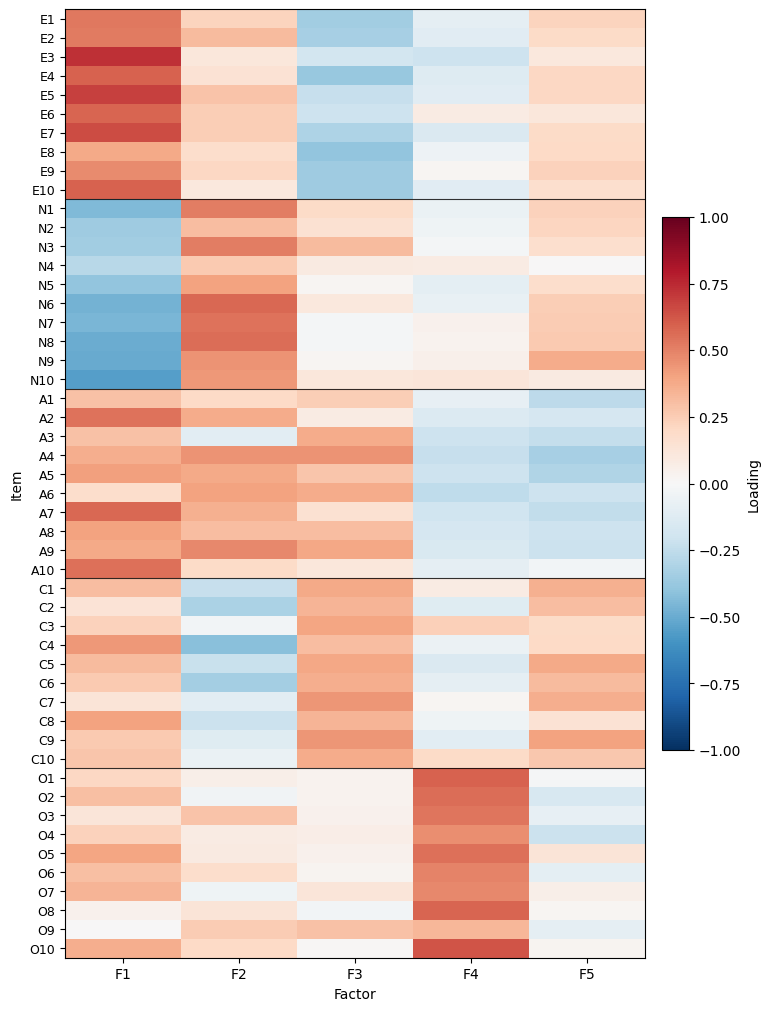

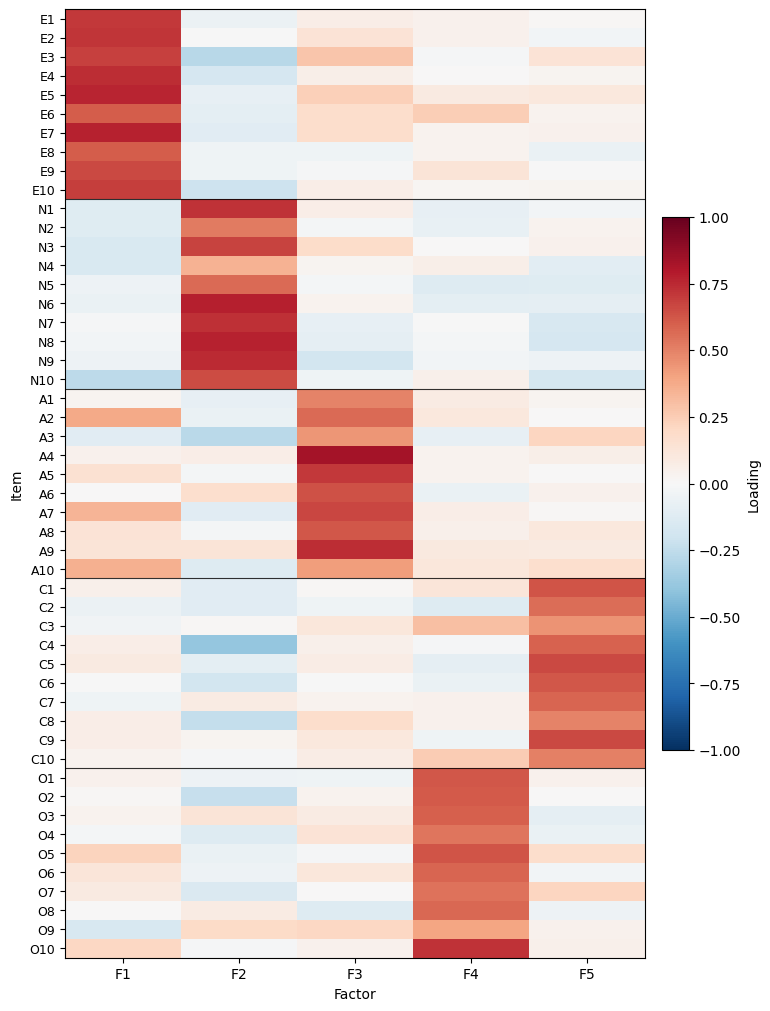

In [25]:
def loading_heatmap(load_df, title):
    M = load_df.values
    fig, ax = plt.subplots(figsize=(7.6, 10.0), constrained_layout=True)
    im = ax.imshow(M, aspect="auto", cmap="RdBu_r", vmin=-1, vmax=1)

    ax.set_yticks(np.arange(len(load_df.index)))
    ax.set_yticklabels(load_df.index, fontsize=9)
    ax.set_xticks(np.arange(load_df.shape[1]))
    ax.set_xticklabels(load_df.columns, fontsize=10)
    ax.set_title(title, fontsize=12, pad=10)
    ax.set_xlabel("Factor")
    ax.set_ylabel("Item")

    for edge in [10, 20, 30, 40]:
        ax.axhline(edge - 0.5, color="black", linewidth=0.8, alpha=0.8)

    cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.03)
    cbar.set_label("Loading", rotation=90)
    plt.show()

loading_heatmap(load0, "")
loading_heatmap(loadV, "")

/usr/local/lib/python3.12/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


Promax factor correlation matrix (Phi):


,F1,F2,F3,F4,F5
F1,1.000000,-0.309435,0.108793,0.159345,0.274931
F2,-0.309435,1.000000,-0.303696,-0.048495,-0.110196
F3,0.108793,-0.303696,1.000000,0.112098,0.238970
F4,0.159345,-0.048495,0.112098,1.000000,0.182464
F5,0.274931,-0.110196,0.238970,0.182464,1.000000


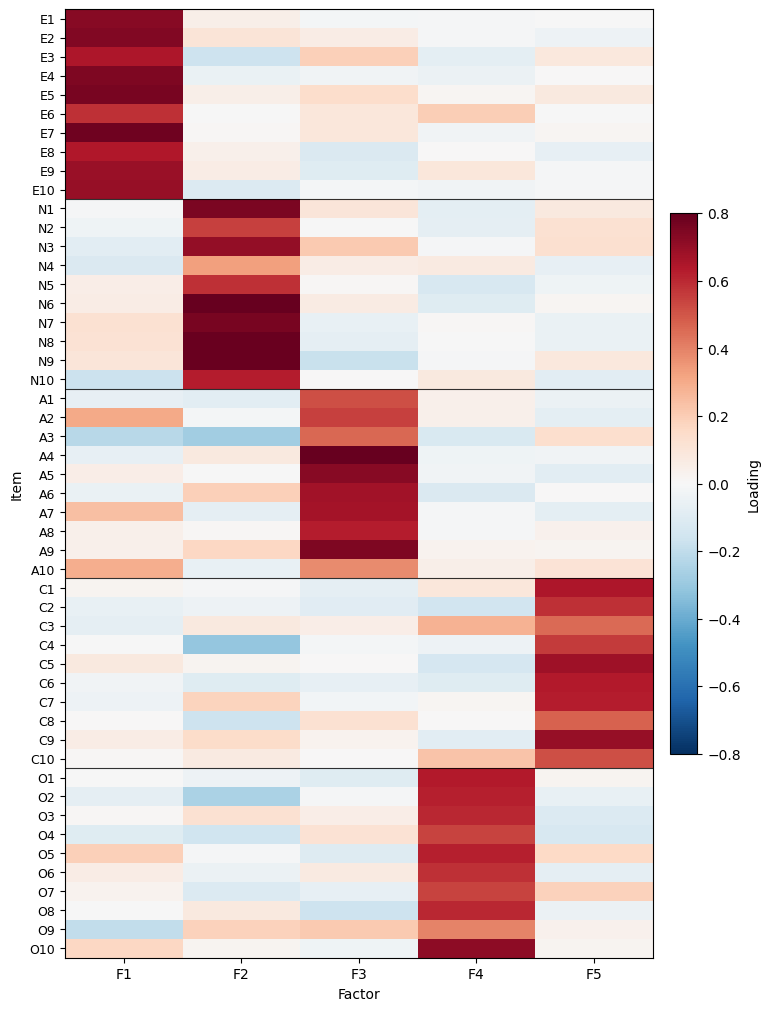

In [26]:
m = 5  # main model

# fit FA with PROMAX rotation (oblique), MINRES extraction on correlation matrix
fa = FactorAnalyzer(n_factors=m, rotation="promax", method="minres", is_corr_matrix=True)
fa.fit(R)

loadP = pd.DataFrame(
    fa.loadings_,
    index=ordered_items,
    columns=[f"F{i}" for i in range(1, m + 1)]
)

# factor correlation matrix (only for oblique rotations like promax)
if hasattr(fa, "phi_") and fa.phi_ is not None:
    phi = pd.DataFrame(fa.phi_, index=loadP.columns, columns=loadP.columns)
    print("Promax factor correlation matrix (Phi):")
    display(phi)

# heatmap
M = loadP.values
fig, ax = plt.subplots(figsize=(7.6, 10.0), constrained_layout=True)
im = ax.imshow(M, aspect="auto", cmap="RdBu_r", vmin=-0.8, vmax=0.8, interpolation="nearest")

ax.set_yticks(np.arange(len(loadP.index)))
ax.set_yticklabels(loadP.index, fontsize=9)
ax.set_xticks(np.arange(m))
ax.set_xticklabels(loadP.columns, fontsize=10)
ax.set_xlabel("Factor")
ax.set_ylabel("Item")

# domain separators (every 10 items)
for edge in [10, 20, 30, 40]:
    ax.axhline(edge - 0.5, color="black", linewidth=0.8, alpha=0.8)

cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.03)
cbar.set_label("Loading", rotation=90)

plt.show()

Residual RMSR (varimax, m=5): 0.0366


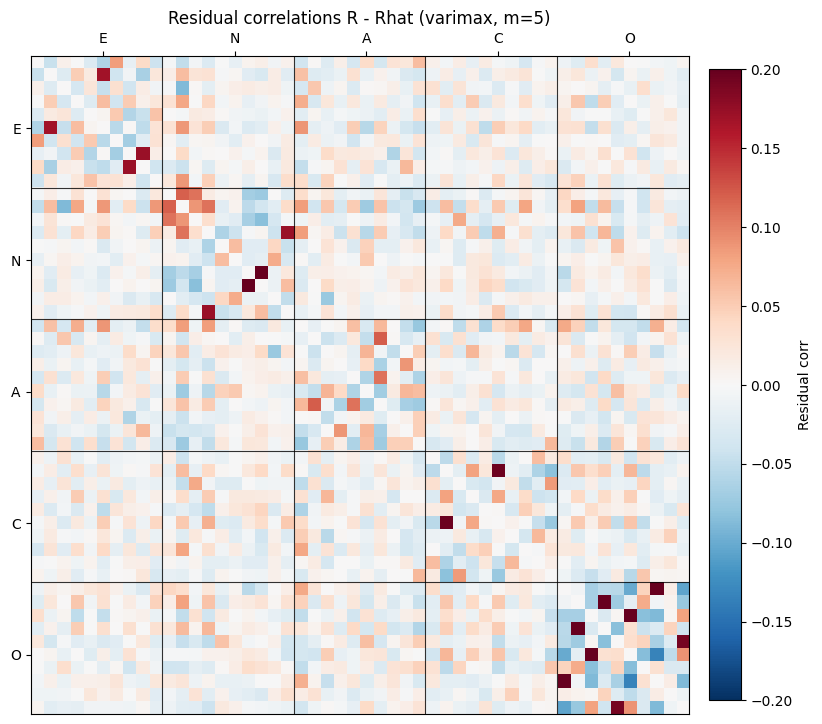

In [27]:
def reproduced_corr(load_df, uniq_series):
    L = load_df.values
    Psi = np.diag(uniq_series.values)
    Rhat = L @ L.T + Psi
    return Rhat

RhatV = reproduced_corr(loadV, uniqV)
residV = R - RhatV
np.fill_diagonal(residV, 0.0)

rmsr = np.sqrt(np.mean(residV[np.triu_indices_from(residV, k=1)]**2))
print(f"Residual RMSR (varimax, m={m}): {rmsr:.4f}")

# quick residual heatmap (optional)
fig, ax = plt.subplots(figsize=(8.2, 7.2), constrained_layout=True)
im = ax.imshow(residV, cmap="RdBu_r", vmin=-0.2, vmax=0.2, interpolation="nearest")
for edge in [10, 20, 30, 40]:
    ax.axhline(edge - 0.5, color="black", linewidth=0.8, alpha=0.8)
    ax.axvline(edge - 0.5, color="black", linewidth=0.8, alpha=0.8)
centers = np.array([5, 15, 25, 35, 45])
ax.set_xticks(centers); ax.set_yticks(centers)
ax.set_xticklabels(["E","N","A","C","O"]); ax.set_yticklabels(["E","N","A","C","O"])
ax.tick_params(top=True, bottom=False, labeltop=True, labelbottom=False)
ax.set_title(f"Residual correlations R - Rhat (varimax, m={m})")
cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.03)
cbar.set_label("Residual corr", rotation=90)
plt.show()

compare different number of factors

/usr/local/lib/python3.12/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


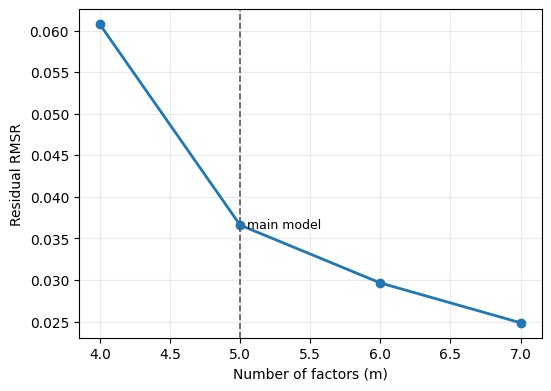

In [28]:
def fit_fa_and_rmsr(R, m, rotation="varimax", method="minres"):
    """
    Fit FA on a correlation matrix and return RMSR of residual correlations.
    RMSR is computed on off-diagonal residuals of R - R_hat.
    """
    fa = FactorAnalyzer(n_factors=m, rotation=rotation, method=method, is_corr_matrix=True)
    fa.fit(R)

    L = fa.loadings_                       # (p x m)
    uniq = fa.get_uniquenesses()           # (p,)
    Rhat = L @ L.T + np.diag(uniq)

    resid = R - Rhat
    np.fill_diagonal(resid, 0.0)

    off = resid[np.triu_indices_from(resid, k=1)]
    rmsr = float(np.sqrt(np.mean(off**2)))
    return rmsr, fa, resid

ms = [4, 5, 6, 7]
rows = []
resid_store = {}

for m in ms:
    rmsr, fa, resid = fit_fa_and_rmsr(R, m, rotation="varimax", method="minres")
    rows.append({"m": m, "RMSR": rmsr})
    resid_store[m] = resid

compare_df = pd.DataFrame(rows).sort_values("m")


fig, ax = plt.subplots(figsize=(5.4, 3.8), constrained_layout=True)
ax.plot(compare_df["m"], compare_df["RMSR"], marker="o", linewidth=2)

ax.set_xlabel("Number of factors (m)")
ax.set_ylabel("Residual RMSR")
ax.grid(alpha=0.25)

ax.axvline(5, color="0.35", linestyle="--", linewidth=1.2)
ax.text(5.02, compare_df.loc[compare_df["m"] == 5, "RMSR"].values[0],
        " main model", va="center", fontsize=9)

plt.show()

try 6 factors

In [29]:
def fit_fa_loadings(R, items, m, rotation="varimax", method="minres"):
    fa = FactorAnalyzer(n_factors=m, rotation=rotation, method=method, is_corr_matrix=True)
    fa.fit(R)
    load = pd.DataFrame(
        fa.loadings_,
        index=items,
        columns=[f"F{i}" for i in range(1, m + 1)]
    )
    comm = pd.Series(fa.get_communalities(), index=items, name="communality")
    uniq = pd.Series(fa.get_uniquenesses(), index=items, name="uniqueness")
    return load, comm, uniq

def plot_loading_heatmap(load_df, title, v=0.80):
    """
    v controls color scale; 0.80 is usually good for FA loadings.
    """
    M = load_df.values
    fig, ax = plt.subplots(figsize=(7.8, 10.2), constrained_layout=True)
    im = ax.imshow(M, aspect="auto", cmap="RdBu_r", vmin=-v, vmax=v, interpolation="nearest")

    ax.set_yticks(np.arange(len(load_df.index)))
    ax.set_yticklabels(load_df.index, fontsize=9)

    ax.set_xticks(np.arange(load_df.shape[1]))
    ax.set_xticklabels(load_df.columns, fontsize=10)

    ax.set_title(title, fontsize=12, pad=10)
    ax.set_xlabel("Factor")
    ax.set_ylabel("Item")

    # domain separators (every 10 items)
    for edge in [10, 20, 30, 40]:
        ax.axhline(edge - 0.5, color="black", linewidth=0.8, alpha=0.8)

    cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.03)
    cbar.set_label("Loading", rotation=90)
    plt.show()

/usr/local/lib/python3.12/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


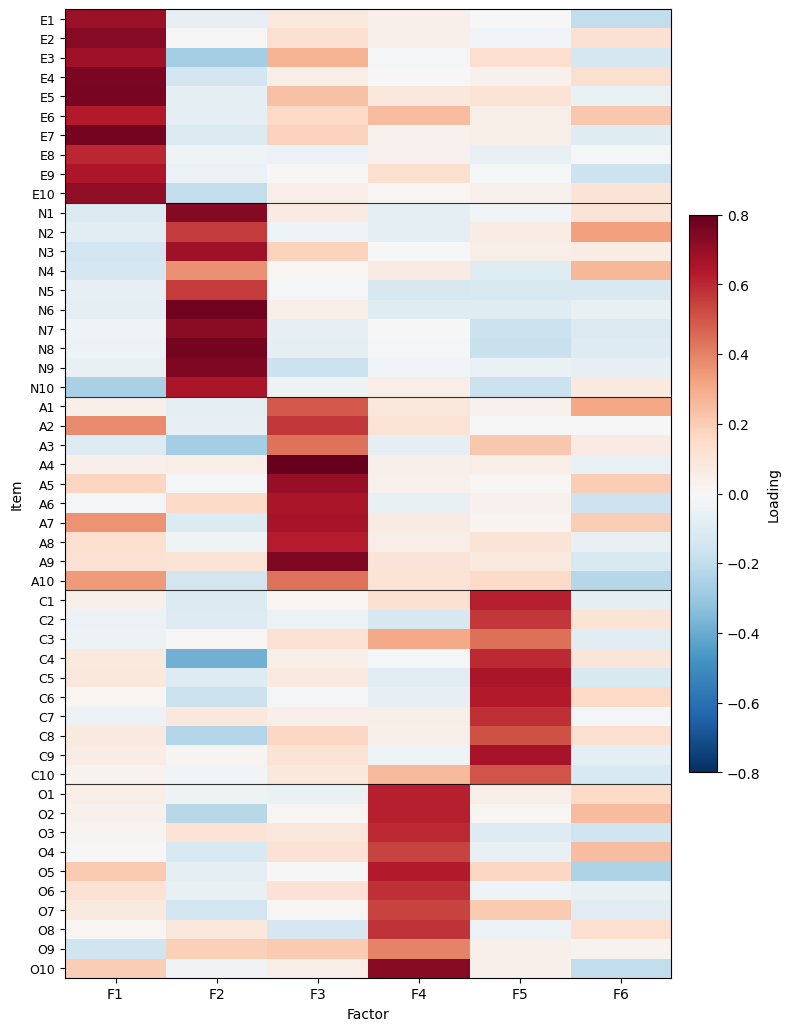

In [33]:
load6, comm6, uniq6 = fit_fa_loadings(R, ordered_items, m=6, rotation="varimax", method="minres")
plot_loading_heatmap(load6, "", v=0.80)

try 7 factors

/usr/local/lib/python3.12/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


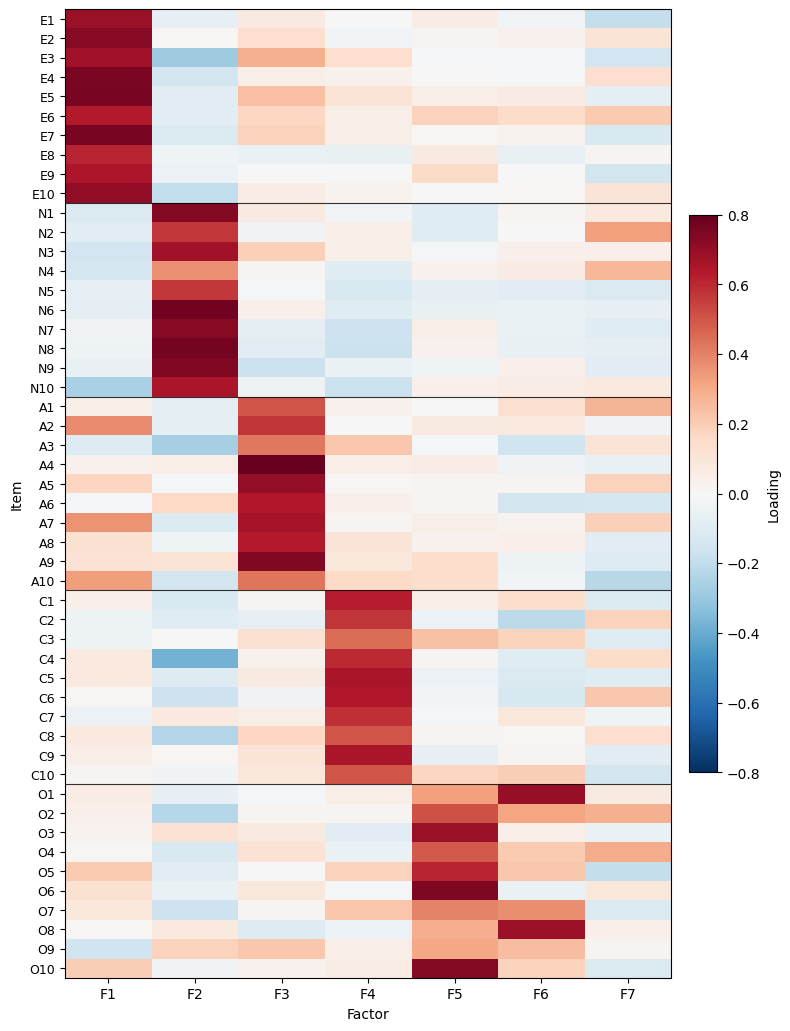

In [30]:
load7, comm7, uniq7 = fit_fa_loadings(R, ordered_items, m=7, rotation="varimax", method="minres")
plot_loading_heatmap(load7, "", v=0.80)